In [24]:
import os
import typing
#from functool import cache 
from datasets import load_dataset, Dataset, IterableDataset
from functools import reduce
chime_path = "/home/niklas/Downloads/Datasets/CHIME6/CHiME6_eval/CHiME6/audio/eval"
#dipco_path = "/home/niklas/Downloads/Datasets/Dipco/"

import os
from datasets import Dataset, Audio
import pandas as pd




In [25]:
import os  
import pandas as pd 
import torchaudio 
import re 
from typing import List
import glob
from datetime import datetime
dipco_path = "/project/data_asr/dipco/Dipco"  
dataset_name = "Dipco"
dev_path = os.path.join(dipco_path, 'audio/dev')
eval_path = os.path.join(dipco_path, 'audio/eval')
transcript_dev_path = os.path.join(dipco_path, 'transcriptions/dev')
transcript_eval_path = os.path.join(dipco_path, 'transcriptions/eval')
version = "vanilla"


def get_formated_date() -> str:
    return datetime.now().strftime("%m/%d/%Y")

def extract_prefix(file_path:str) -> str:
    pattern = r'^(.*)\.json$'
    match = re.search(pattern, file_path)
    if match:
        prefix = match.group(1)
        return prefix
    else :
        raise ValueError
    




def list_json_files(directory):
    # Construct the file path pattern
    pattern = os.path.join(directory, '*.json')
    
    # Use glob to get a list of files matching the pattern
    json_files = glob.glob(pattern)
    
    return json_files

def load_and_concatenate_json_files(directory):
    json_files = list_json_files(directory)
    
    # List to hold individual DataFrames
    data_frames = []
    
    for json_file in json_files:
        # Read the JSON file into a DataFrame
        df = pd.read_json(json_file)
        data_frames.append(df)
    
    # Concatenate all DataFrames into a single DataFrame
    combined_df = pd.concat(data_frames, ignore_index=True)
    
    return combined_df


df = load_and_concatenate_json_files(transcript_dev_path)
eval_df = load_and_concatenate_json_files(transcript_eval_path)
#df = pd.read_json(full_path)
transcriptions = df['words']

print(df.columns)
print(df['start_time'].head(1))
#print(full_path)



Index(['start_time', 'end_time', 'words', 'ref', 'session_id', 'speaker_id',
       'gender', 'nativeness', 'mother_tongue'],
      dtype='object')
0    {'U03': '00:00:10.15', 'U05': '00:00:10.15', '...
Name: start_time, dtype: object


In [26]:
from transformers import WhisperFeatureExtractor
from typing import Dict
import pprint
import torch 
import matplotlib.pyplot as plt 
import multiprocessing
import inspect
model_name = "openai/whisper-large"
feature_extractor = WhisperFeatureExtractor.from_pretrained(model_name)
print(inspect.signature(feature_extractor))
def expand_start_time(row):
    start_time_dict = row['start_time']
    rows = []
    for key, time_str in start_time_dict.items():
        new_row = row.copy()
        new_row['audio'] = key
        new_row['start'] = time_str
        rows.append(new_row)
    return pd.DataFrame(rows)

# Function to convert time string to seconds
def time_to_seconds(time_str):
    h, m, s = map(float, time_str.split(':'))
    
    return h * 3600 + m * 60 + s




def get_corresponding_end_time(dict:dict, key:str):
    end_time = [v for k,v in dict if k==key]
    return end_time



# removal of the end_time

#expanded_df = expanded_df.drop(expanded_df['audio']=='close-talk')


# U01 - U05 & CH 1 - 7 

# Function to generate microphone paths
def generate_microphone_paths(row):
    paths = []
    for i in range(1, 7):
        path = f"{dev_path}/{row['session_id']}_{row['audio']}.CH{i}.wav"
        paths.append(path)

    path = f"{dev_path}/{row['session_id']}_{row['speaker_id']}.wav"
    paths.append(path)
    return paths





#change the seconds to frames
def get_Frames(starting_second:float, sample_rate:int, end_second:float )-> List[int] :
     return [int(starting_second*sample_rate), int(end_second*sample_rate)]


#columns_to_drop = ['mother_tongue', 'ref', 'nativeness', 'audio', 'session_id','speaker_id', 'gender']


# print(expanded_df['duration'].max()) yielded that the biggest in the dipco dataset was above 60 seconds for those an additional separation is required 
#expanded_df = expanded_df.drop(columns=columns_to_drop)
# sorting for cache efficiency so far no speedup 
def validate_frames_column(frames_list):
    return len(frames_list) == 2



# Drop the original 'frames' column if no longer needed
"""expanded_df = expanded_df.drop(columns=['frames'])

expanded_df = expanded_df.sort_values(by=['file_path','start'])
expanded_df = expanded_df.reset_index(drop=True)
grouped = expanded_df.groupby(['words'])
count_df = grouped.size().reset_index(name='counts')
first_group_key = list(grouped.groups.keys())[0]
first_group = grouped.get_group(first_group_key)
print(first_group)
print(first_group['file_path'].value_counts())
print(count_df)"""




#expanded_df['logmel'] = expanded_df.apply(lambda row: get_logmel(row['startframe'], row['endframe'], row['file_path']), axis=1)
def get_logmel(startframe: int, endframe: int, filepath: str) -> Dict[str, torch.Tensor]:
    sliced_waveform = load_audio_segment(filepath=filepath, start_frame=startframe, end_frame=endframe)
    features = feature_extractor(sliced_waveform.numpy(), sampling_rate=16000, return_tensors='pt')
    return features


    
def load_audio_segment(filepath, start_frame, end_frame):
    waveform, sample_rate = torchaudio.load(filepath)
    return waveform[:, start_frame:end_frame], sample_rate    
#print(expanded_df)
#print(expanded_df.head(10))


def string_parsing(dataframe):
    # Apply the function to each row and concatenate the results
    dataframe = pd.concat([expand_start_time(row) for _, row in dataframe.iterrows()], ignore_index=True)
    # Drop the original 'start_time' column
    dataframe = dataframe.drop(columns=['start_time'])
    dataframe['start'] = dataframe['start'].apply(time_to_seconds)
    dataframe['end'] = dataframe.apply(lambda row: row['end_time'][row['audio']], axis=1)
    dataframe['end'] = dataframe['end'].apply(time_to_seconds)
    dataframe = dataframe.drop(columns=['end_time'])
    # Apply the function to generate the paths for each row
    dataframe['file_path'] = dataframe.apply(generate_microphone_paths, axis=1)
    # Expand the DataFrame to include the microphone paths
    dataframe = dataframe.explode('file_path').reset_index(drop=True)
    dataframe['frames'] = dataframe.apply(lambda row: get_Frames(row['start'], 16000, row['end']), axis=1)
    dataframe = dataframe[dataframe['audio'] != 'close-talk']
    #get the maximum speaking duration 
    dataframe['duration'] = dataframe.apply(lambda row: row['end'] - row['start'], axis=1)
    if dataframe['frames'].isnull().any():
        raise ValueError("The 'frames' column contains null values.")
    if not dataframe['frames'].apply(validate_frames_column).all():
        raise ValueError("Each entry in the 'frames' column must be a list of exactly two elements [startframe, endframe].")
    dataframe[['startframe', 'endframe']] = pd.DataFrame(dataframe['frames'].tolist(), index=dataframe.index)
    print(dataframe.shape)
    pprint.pp(dataframe.head(10))
    dataframe['num_frames'] = dataframe['endframe'] - dataframe['startframe']
    # handle chime and dipco data differently
    if 'nativeness' in dataframe.columns:
        dataframe.drop(columns=['endframe', 'session_id', 'speaker_id','gender', 'nativeness','mother_tongue','audio','start','end','endframe','duration','frames', 'ref'], inplace=True)
    else:
        dataframe.drop(columns=['end_time','start_time'], inplace=True)
        
        
        
    
    dataframe.reset_index(drop=True, inplace=True)
    return dataframe 

expanded_df = string_parsing(df)
eval_df = string_parsing(eval_df)

    









(raw_speech: Union[numpy.ndarray, List[float], List[numpy.ndarray], List[List[float]]], truncation: bool = True, pad_to_multiple_of: Optional[int] = None, return_tensors: Union[str, transformers.utils.generic.TensorType, NoneType] = None, return_attention_mask: Optional[bool] = None, padding: Optional[str] = 'max_length', max_length: Optional[int] = None, sampling_rate: Optional[int] = None, do_normalize: Optional[bool] = None, device: Optional[str] = 'cpu', return_token_timestamps: Optional[bool] = None, **kwargs) -> transformers.feature_extraction_utils.BatchFeature
(128555, 15)
         words         ref session_id speaker_id gender nativeness  \
0  speaker one  close-talk        S04        P13   male     native   
1  speaker one  close-talk        S04        P13   male     native   
2  speaker one  close-talk        S04        P13   male     native   
3  speaker one  close-talk        S04        P13   male     native   
4  speaker one  close-talk        S04        P13   male     na

In [27]:

import torch
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline
from datasets import Features, Value
from transformers import WhisperTokenizer
from datasets import load_dataset
device = "cuda:0" 
torch_dtype = torch.float32 if torch.cuda.is_available() else torch.float32
model_id = "openai/whisper-tiny"
features = Features({
    'file_path': Value('string'),
    'words': Value('string'),
     'startframe': Value('int64'),
    'num_frames': Value('int64'),
    
    
})
tokenizer = WhisperTokenizer.from_pretrained("openai/whisper-large-v3", task="transcribe", language="en")
def Hug_dataset_creation(expanded_df, mode):
    dataset = Dataset.from_pandas(expanded_df, features=features)
    shuffled_dataset = dataset.shuffle(seed=42)  
    if mode == 'train':
        return shuffled_dataset.select(range(100))
    else:
          return shuffled_dataset.select(range(100))
        

    
train_dataset = Hug_dataset_creation(expanded_df, mode='train')
    
eval_dataset = Hug_dataset_creation(eval_df, mode='eval')


#dataset = dataset.to_iterable_dataset()
print(train_dataset[0])
import inspect
print(inspect.signature(WhisperTokenizer))



def prepare_dataset(batch):
    # load and resample audio data from 48 to 16kHz
    print(batch["file_path"])
   
  
    waveform,sample_rate = torchaudio.load(batch["file_path"], frame_offset=batch["startframe"], num_frames=batch["num_frames"])
    input = waveform.squeeze().numpy()
    batch["input_features"]= feature_extractor(input, sampling_rate=sample_rate).input_features[0]
        
   
    
    

    # compute log-Mel input features from input audio array


    # encode target text to label ids
    batch["labels"] = tokenizer(batch["words"]).input_ids
    return batch

train_dataset = train_dataset.map(prepare_dataset)
eval_dataset = train_dataset.map(prepare_dataset)
train_dataset.save_to_disk("train.hf")
eval_dataset.save_to_disk("eval.hf")
import os
from datasets import load_from_disk, Dataset

# Define the path to the dataset directory
dataset_path = "train.hf"

# Check if the directory exists
if os.path.exists(dataset_path) and os.path.isdir(dataset_path):
    try:
        # Attempt to load the dataset
        dataset = load_from_disk(dataset_path)
        print("Dataset loaded.")
    except Exception as e:
        print(f"error while loading the dataset: {e}")
else:
    print(f"The directory '{dataset_path}' does not exist or is not a directory.")
model = AutoModelForSpeechSeq2Seq.from_pretrained(
    model_id, torch_dtype=torch_dtype, low_cpu_mem_usage=True, use_safetensors=True,  
)
model.generation_config.language = "English"
model.generation_config.task = "transcribe"

model.generation_config.forced_decoder_ids = None
model.to(device)



{'file_path': '/project/data_asr/dipco/Dipco/audio/dev/S05_U05.CH5.wav', 'words': "i don't know they were saying that's like a natural habitat but i didn't see much", 'startframe': 34964480, 'num_frames': 66240}
(vocab_file, merges_file, normalizer_file=None, errors='replace', unk_token='<|endoftext|>', bos_token='<|endoftext|>', eos_token='<|endoftext|>', pad_token=None, add_prefix_space=False, language=None, task=None, predict_timestamps=False, **kwargs)


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

/project/data_asr/dipco/Dipco/audio/dev/S05_U05.CH5.wav
/project/data_asr/dipco/Dipco/audio/dev/S02_U03.CH2.wav
/project/data_asr/dipco/Dipco/audio/dev/S10_U02.CH6.wav
/project/data_asr/dipco/Dipco/audio/dev/S05_U02.CH1.wav
/project/data_asr/dipco/Dipco/audio/dev/S10_U04.CH5.wav
/project/data_asr/dipco/Dipco/audio/dev/S02_U04.CH2.wav
/project/data_asr/dipco/Dipco/audio/dev/S09_U01.CH6.wav
/project/data_asr/dipco/Dipco/audio/dev/S04_U05.CH3.wav
/project/data_asr/dipco/Dipco/audio/dev/S04_U02.CH4.wav
/project/data_asr/dipco/Dipco/audio/dev/S05_U03.CH5.wav
/project/data_asr/dipco/Dipco/audio/dev/S05_P19.wav
/project/data_asr/dipco/Dipco/audio/dev/S04_U01.CH4.wav
/project/data_asr/dipco/Dipco/audio/dev/S04_U01.CH4.wav
/project/data_asr/dipco/Dipco/audio/dev/S02_U04.CH2.wav
/project/data_asr/dipco/Dipco/audio/dev/S05_U02.CH4.wav
/project/data_asr/dipco/Dipco/audio/dev/S09_U05.CH1.wav
/project/data_asr/dipco/Dipco/audio/dev/S10_U02.CH1.wav
/project/data_asr/dipco/Dipco/audio/dev/S09_U05.CH5.

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

/project/data_asr/dipco/Dipco/audio/dev/S05_U05.CH5.wav
/project/data_asr/dipco/Dipco/audio/dev/S02_U03.CH2.wav
/project/data_asr/dipco/Dipco/audio/dev/S10_U02.CH6.wav
/project/data_asr/dipco/Dipco/audio/dev/S05_U02.CH1.wav
/project/data_asr/dipco/Dipco/audio/dev/S10_U04.CH5.wav
/project/data_asr/dipco/Dipco/audio/dev/S02_U04.CH2.wav
/project/data_asr/dipco/Dipco/audio/dev/S09_U01.CH6.wav
/project/data_asr/dipco/Dipco/audio/dev/S04_U05.CH3.wav
/project/data_asr/dipco/Dipco/audio/dev/S04_U02.CH4.wav
/project/data_asr/dipco/Dipco/audio/dev/S05_U03.CH5.wav
/project/data_asr/dipco/Dipco/audio/dev/S05_P19.wav
/project/data_asr/dipco/Dipco/audio/dev/S04_U01.CH4.wav
/project/data_asr/dipco/Dipco/audio/dev/S04_U01.CH4.wav
/project/data_asr/dipco/Dipco/audio/dev/S02_U04.CH2.wav
/project/data_asr/dipco/Dipco/audio/dev/S05_U02.CH4.wav
/project/data_asr/dipco/Dipco/audio/dev/S09_U05.CH1.wav
/project/data_asr/dipco/Dipco/audio/dev/S10_U02.CH1.wav
/project/data_asr/dipco/Dipco/audio/dev/S09_U05.CH5.

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Dataset loaded.


WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 384)
      (layers): ModuleList(
        (0-3): 4 x WhisperEncoderLayer(
          (self_attn): WhisperSdpaAttention(
            (k_proj): Linear(in_features=384, out_features=384, bias=False)
            (v_proj): Linear(in_features=384, out_features=384, bias=True)
            (q_proj): Linear(in_features=384, out_features=384, bias=True)
            (out_proj): Linear(in_features=384, out_features=384, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          

In [28]:



processor = AutoProcessor.from_pretrained(model_id, language='en', task="transcribe")

pipe = pipeline(
    "automatic-speech-recognition",
    model=model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    max_new_tokens=128,
    chunk_length_s=30,
    batch_size=16,
    return_timestamps=True,
    torch_dtype=torch_dtype,
    device=device,
 
)

from tqdm import tqdm 

expanded_df['results'] = ''
expanded_df = expanded_df.head(10)
expanded_df.reset_index(drop=True, inplace=True)
print(expanded_df.shape)
# load audio and pad/trim it to fit 30 seconds

def transcribe_audio(expanded_df):
    
    for i in tqdm(range(expanded_df.shape[0])):
        #audio = whisper.load_audio('output_segments/segment_' + str(i + 1) + '.wav')
        audio,_ = torchaudio.load(expanded_df['file_path'][i], frame_offset=expanded_df['startframe'][i], num_frames=expanded_df['num_frames'][i])
        audio_data = audio.squeeze().numpy()
        print(audio_data.shape)
        result = pipe(audio_data, generate_kwargs={"language": "english"})

       
        expanded_df.loc[i,'results'] = result['text']
    
    
    return expanded_df
print(expanded_df.columns)
expanded_df=transcribe_audio(expanded_df)
expanded_df.to_csv('dipco_dev.csv', index=False)

#cProfile.run("transcribe_audio(expanded_df,model)", 'whisper_resultssmall.prof')


#cProfile.run("transcribe_audio(expanded_df,model)", 'whisper_resultssmall.prof')

# result the load audio function takes a quarter of the time when the snippets are cut into lenghts of 1:10th


(10, 5)
Index(['words', 'file_path', 'startframe', 'num_frames', 'results'], dtype='object')


  0%|          | 0/10 [00:00<?, ?it/s]/home/niklas/PycharmProjects/Whisper/.venv/lib/python3.10/site-packages/transformers/models/whisper/generation_whisper.py:483: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
 10%|█         | 1/10 [00:00<00:01,  6.38it/s]

(22080,)


/home/niklas/PycharmProjects/Whisper/.venv/lib/python3.10/site-packages/transformers/models/whisper/generation_whisper.py:483: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
 20%|██        | 2/10 [00:00<00:01,  4.44it/s]/home/niklas/PycharmProjects/Whisper/.venv/lib/python3.10/site-packages/transformers/models/whisper/generation_whisper.py:483: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
 30%|███       | 3/10 [00:00<00:01,  5.44it/s]

(22080,)
(22080,)


...

(22080,)


/home/niklas/PycharmProjects/Whisper/.venv/lib/python3.10/site-packages/transformers/models/whisper/generation_whisper.py:483: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
 80%|████████  | 8/10 [00:01<00:00,  4.07it/s]/home/niklas/PycharmProjects/Whisper/.venv/lib/python3.10/site-packages/transformers/models/whisper/generation_whisper.py:483: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
 90%|█████████ | 9/10 [00:01<00:00,  4.70it/s]

(22080,)
(22080,)


/home/niklas/PycharmProjects/Whisper/.venv/lib/python3.10/site-packages/transformers/models/whisper/generation_whisper.py:483: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
100%|██████████| 10/10 [00:02<00:00,  4.54it/s]

(22080,)


In [29]:
# chime normalization
import jiwer
from jiwer.transforms import RemoveKaldiNonWords
from lhotse.recipes.chime6 import TimeFormatConverter, normalize_text_chime6
def chime_normalisation(input:str) -> str:
    jiwer_chime6_scoring = jiwer.Compose(
    [
        RemoveKaldiNonWords(),
        jiwer.SubstituteRegexes({r"\"": " ", "^[ \t]+|[ \t]+$": "", r"\u2019": "'"}),
        jiwer.RemoveEmptyStrings(),
        jiwer.RemoveMultipleSpaces(),
    ])
    jiwer_chime7_scoring = jiwer.Compose(
    [
        jiwer.SubstituteRegexes(
            {
                "(?:^|(?<= ))(hm|hmm|mhm|mmh|mmm)(?:(?= )|$)": "hmmm",
                "(?:^|(?<= ))(uhm|um|umm|umh|ummh)(?:(?= )|$)": "ummm",
                "(?:^|(?<= ))(uh|uhh)(?:(?= )|$)": "uhhh",
            }
        ),
        jiwer.RemoveEmptyStrings(),
        jiwer.RemoveMultipleSpaces(),
    ])
    def chime6_norm_scoring(txt):
        return jiwer_chime6_scoring(normalize_text_chime6(txt, normalize="kaldi"))


# here we also normalize non-words sounds such as hmmm which are quite a lot !
# you are free to use whatever normalization you prefer for training but this
# normalization below will be used when we score your submissions.
    def chime7_norm_scoring(txt):
        return jiwer_chime7_scoring(
            jiwer_chime6_scoring(
                normalize_text_chime6(txt, normalize="kaldi")
            )  # noqa: E731
        )  # noqa: E731
    return chime7_norm_scoring(input)



In [30]:
# peft 
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
# Define LoRA Config
# Print out all the module names in the model
for name, module in model.named_modules():
    print(name)
'''linear_modules = [name for name, module in model.named_modules() if isinstance(module, torch.nn.Linear)]
target_modules = [name for name in linear_modules if name.startswith('model.encoder.layers')]
text_lora_config = LoraConfig(
    r=args.rank,
    lora_alpha=args.rank,
    init_lora_weights="gaussian",
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
)

lora_config = LoraConfig(
 r=16,
 lora_alpha=32,
 target_modules=target_modules,
 lora_dropout=0.05,
 bias="none",
 task_type=TaskType.SEQ_2_SEQ_LM
)
# prepare int-8 model for training
model = prepare_model_for_kbit_training(model)
print ([module for module in model.modules()])
# add LoRA adaptor
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()'''


model
model.encoder
model.encoder.conv1
model.encoder.conv2
model.encoder.embed_positions
model.encoder.layers
model.encoder.layers.0
model.encoder.layers.0.self_attn
model.encoder.layers.0.self_attn.k_proj
model.encoder.layers.0.self_attn.v_proj
model.encoder.layers.0.self_attn.q_proj
model.encoder.layers.0.self_attn.out_proj
model.encoder.layers.0.self_attn_layer_norm
model.encoder.layers.0.activation_fn
model.encoder.layers.0.fc1
model.encoder.layers.0.fc2
model.encoder.layers.0.final_layer_norm
model.encoder.layers.1
model.encoder.layers.1.self_attn
model.encoder.layers.1.self_attn.k_proj
model.encoder.layers.1.self_attn.v_proj
model.encoder.layers.1.self_attn.q_proj
model.encoder.layers.1.self_attn.out_proj
model.encoder.layers.1.self_attn_layer_norm
model.encoder.layers.1.activation_fn
model.encoder.layers.1.fc1
model.encoder.layers.1.fc2
model.encoder.layers.1.final_layer_norm
model.encoder.layers.2
model.encoder.layers.2.self_attn
model.encoder.layers.2.self_attn.k_proj
model.

'linear_modules = [name for name, module in model.named_modules() if isinstance(module, torch.nn.Linear)]\ntarget_modules = [name for name in linear_modules if name.startswith(\'model.encoder.layers\')]\ntext_lora_config = LoraConfig(\n    r=args.rank,\n    lora_alpha=args.rank,\n    init_lora_weights="gaussian",\n    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],\n)\n\nlora_config = LoraConfig(\n r=16,\n lora_alpha=32,\n target_modules=target_modules,\n lora_dropout=0.05,\n bias="none",\n task_type=TaskType.SEQ_2_SEQ_LM\n)\n# prepare int-8 model for training\nmodel = prepare_model_for_kbit_training(model)\nprint ([module for module in model.modules()])\n# add LoRA adaptor\nmodel = get_peft_model(model, lora_config)\nmodel.print_trainable_parameters()'

In [51]:
# training of the model 
from transformers import Seq2SeqTrainer
from transformers import Seq2SeqTrainingArguments
import torch
import json 
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # split inputs and labels since they have to be of different lengths and need different padding methods
        # first treat the audio inputs by simply returning torch tensors
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        # get the tokenized label sequences
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        # pad the labels to max length
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # replace padding with -100 to ignore loss correctly
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        # if bos token is appended in previous tokenization step,
        # cut bos token here as it's append later anyways
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels

        return batch
data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    decoder_start_token_id=model.config.decoder_start_token_id,
)


import evaluate
metric = evaluate.load("wer")
# 
def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    # replace -100 with the pad_token_id
    label_ids[label_ids == -100] = tokenizer.pad_token_id

    # we do not want to group tokens when computing the metrics
    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer}
def compute_chime_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    # replace -100 with the pad_token_id
    label_ids[label_ids == -100] = tokenizer.pad_token_id

    # we do not want to group tokens when computing the metrics
    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    results = {"predictions": pred_str, "labels": label_str}
    results_directory = str(f"{model_id}_{dataset_name}_{version}_{get_formated_date()}")
    if not os.path.exists(results_directory):
        os.makedirs(results_directory)
    file_path = os.path.join(results_directory, "results.json")
    with open(file_path, "w") as f:
        json.dump(results, f, indent=4)

# Define the file path


# Write the evaluation results to the file
    # Example evaluation results
    chime_normalized_reference = [chime_normalisation(reference) for reference in label_str]
    chime_normalized_prediction = [chime_normalisation(pred) for pred in pred_str]

    #wer = 100 * metric.compute(predictions=chime_normalized_prediction, references=chime_normalized_reference)
    wer = jiwer.wer(list(chime_normalized_prediction), list(chime_normalized_reference))

    return {"wer": wer}
training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-small-hi",  # change to a repo name of your choice
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,  # increase by 2x for every 2x decrease in batch size
    learning_rate=1e-5,
    warmup_steps=0,
    max_steps=300,#4000
    gradient_checkpointing=True,
    fp16=True,
    eval_strategy="steps",
    per_device_eval_batch_size=8,
    predict_with_generate=True,
    generation_max_length=225,
    save_steps=100,
    eval_steps=100,    
    logging_steps=25,
    report_to=["tensorboard"],
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
 
)
#english_feature_extractor = processor.feature_extractor(language='en')
print(inspect.signature(processor.feature_extractor))
trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_chime_metrics,
    tokenizer=processor.feature_extractor,
)
processor.save_pretrained(training_args.output_dir)

eval_results = trainer.train()

# Print evaluation results



# Save evaluation results to a JSON file

    

max_steps is given, it will override any value given in num_train_epochs


(raw_speech: Union[numpy.ndarray, List[float], List[numpy.ndarray], List[List[float]]], truncation: bool = True, pad_to_multiple_of: Optional[int] = None, return_tensors: Union[str, transformers.utils.generic.TensorType, NoneType] = None, return_attention_mask: Optional[bool] = None, padding: Optional[str] = 'max_length', max_length: Optional[int] = None, sampling_rate: Optional[int] = None, do_normalize: Optional[bool] = None, device: Optional[str] = 'cpu', return_token_timestamps: Optional[bool] = None, **kwargs) -> transformers.feature_extraction_utils.BatchFeature


/home/niklas/PycharmProjects/Whisper/.venv/lib/python3.10/site-packages/torch/utils/checkpoint.py:464: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
`use_cache = True` is incompatible with gradient checkpointing. Setting `use_cache = False`...


Step,Training Loss,Validation Loss,Wer
100,0.493200,0.262444,0.474199
200,0.007300,0.005021,0.358025
300,0.001900,0.001888,0.184244


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50358, 50359, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}
/home/niklas/PycharmProjects/Whisper/.venv/lib/python3.10/site-packages/torch/utils/checkpoi

Directory already exists


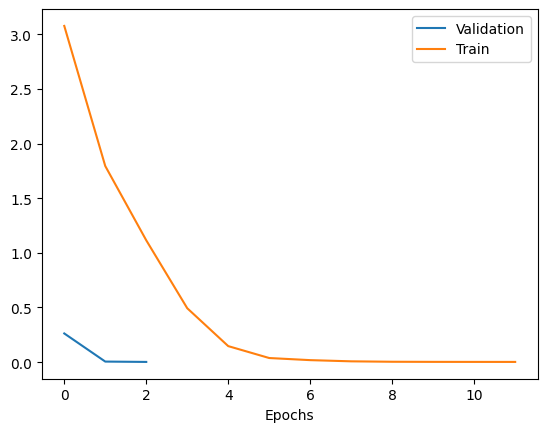

In [65]:
df_log = pd.DataFrame(trainer.state.log_history)
# visualization of the loss during training 
(df_log.dropna(subset=["eval_loss"]).reset_index()["eval_loss"]
.plot(label="Validation"))
df_log.dropna(subset=["loss"]).reset_index()["loss"].plot(label="Train")

plt.xlabel("Epochs")
plt.legend(loc="upper right")

filepath = f'Figures/Training/LOSS/{dataset_name}/{model_id}/{version}/{get_formated_date()}'
try:
    os.makedirs(filepath)
except FileExistsError:
    print("Directory already exists")
finally:
    plt.savefig(filepath + "1", format='png')
    




Directory already exists


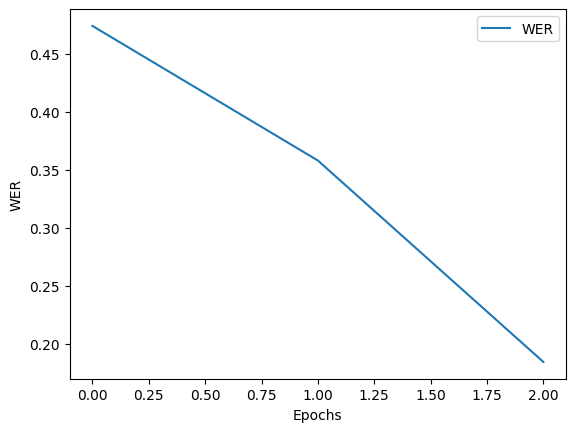

In [64]:
#print evaluation of WER over training 
df_log = pd.DataFrame(trainer.state.log_history)
# visualization of the loss during training 
(df_log.dropna(subset=["eval_wer"]).reset_index()["eval_wer"].plot(label="WER"))
plt.xlabel("Epochs")
plt.ylabel("WER")
plt.legend(loc="upper right")

min_eval_wer = df_log['eval_wer'].min()
def format_wer(wer):
  """Formats a WER value as a string with the decimal point replaced by an underscore.

  Args:
    wer: The WER value as a float.

  Returns:
    The formatted WER as a string.
  """

  wer_str = f"{wer:.3f}"  # Format the WER to three decimal places
  return wer_str.replace(".", "_")
min_eval_wer_str = format_wer(min_eval_wer)
filepath = f'Figures/Training/WER/{dataset_name}/{min_eval_wer_str}/{model_id}/{version}/{get_formated_date()}'

try:
    os.makedirs(filepath)
except FileExistsError:
    print("Directory already exists")
finally:
    plt.savefig(f'{filepath}/test.png', format='png')
    


In [32]:
# Chime Normalization of the results 
model_path = "./whisper-small-hi/checkpoint-101"

# Load the model from the safetensors file
model = AutoModelForSpeechSeq2Seq.from_pretrained(model_path, from_tf=False, config=model_path + "/config.json")
tokenizer = WhisperTokenizer.from_pretrained("openai/whisper-large-v3", task="transcribe", language="en")
# Load the tokenizer (if necessary)



# Example input
print(expanded_df.columns)


ds = load_dataset("hf-internal-testing/librispeech_asr_dummy", "clean", split="validation")
from tqdm import tqdm



# Iterate over the dataset with progress tracking
eval_temp = pd.DataFrame(columns=['results_trained'])
for i, example in tqdm(enumerate(eval_dataset), total=len(eval_dataset)):
    sample = ds[0]["audio"]
    input_features = processor(sample["array"], sampling_rate=sample["sampling_rate"], return_tensors="pt").input_features 
    outputs = model.generate(input_features)
    transcription = processor.batch_decode(outputs, skip_special_tokens=True)
   
    eval_temp.loc[i, "results_trained"]= transcription
    


   

   
    



print(inspect.signature(model))
# Generate the output

# Decode the output





Index(['words', 'file_path', 'startframe', 'num_frames', 'results'], dtype='object')


100%|██████████| 100/100 [00:53<00:00,  1.86it/s]

(*args, **kwargs)


In [33]:
## visualization of the layers 
import torch.nn as nn 
print([module for module in model.modules() if not isinstance(module, nn.Sequential)])

name_of_part_to_train = 'encoder'
part_to_train = getattr(model, name_of_part_to_train, None)

#for param in part_to_train.parameters():
  #  print(type(param))




[WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 384)
      (layers): ModuleList(
        (0-3): 4 x WhisperEncoderLayer(
          (self_attn): WhisperSdpaAttention(
            (k_proj): Linear(in_features=384, out_features=384, bias=False)
            (v_proj): Linear(in_features=384, out_features=384, bias=True)
            (q_proj): Linear(in_features=384, out_features=384, bias=True)
            (out_proj): Linear(in_features=384, out_features=384, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
         

In [34]:
#freezing parameters of the encoder


In [35]:
from torch import optim




Index(['words', 'file_path', 'startframe', 'num_frames', 'results'], dtype='object')
0    22080
1    22080
2    22080
3    22080
4    22080
5    22080
6    22080
7    22080
8    22080
9    22080
Name: num_frames, dtype: int64
Empty DataFrame
Columns: [words, file_path, startframe, num_frames, results, frame_diff]
Index: []


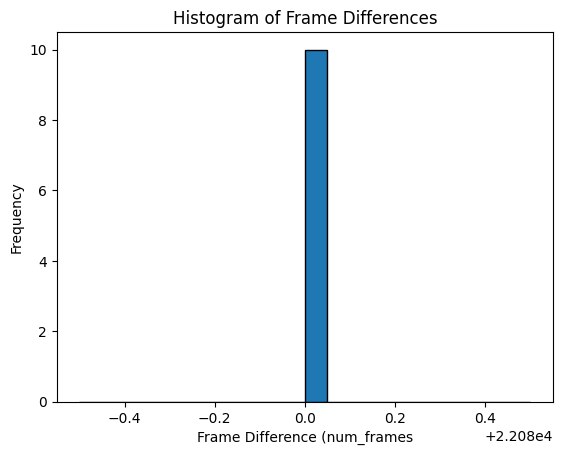

In [36]:
import matplotlib.pyplot as plt
print(expanded_df.columns)
expanded_df['frame_diff'] = expanded_df['num_frames'] 
print(expanded_df['num_frames'].nsmallest(20))
filtered_df = expanded_df[expanded_df['frame_diff'] < 0]
print(filtered_df)
# Plot the histogram with 20 bins
plt.hist(expanded_df['frame_diff'], bins=20, edgecolor='black')
plt.title('Histogram of Frame Differences')
plt.xlabel('Frame Difference (num_frames')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [37]:
print(dir(model))


['T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_assisted_decoding', '_auto_class', '_autoset_attn_implementation', '_backward_compatibility_gradient_checkpointing', '_backward_hooks', '_backward_pre_hooks', '_beam_search', '_buffers', '_call_impl', '_check_and_enable_flash_attn_2', '_check_and_enable_sdpa', '_check_decoder_input_ids', '_compiled_call_impl', '_constrained_beam_search', '_contrastive_search', '_convert_head_mask_to_5d', '_copy_lm_head_original_to_resized', '_create_repo', '_dispatch_accelerate_model', '_dola_decoding', '_expand_inputs_for_generation', '_expand_variables_for_

In [38]:
import meeteval
from meeteval.viz.visualize import AlignmentVisualization

folder = r'https://raw.githubusercontent.com/fgnt/meeteval/main/'
av = AlignmentVisualization(
    meeteval.io.load(folder + 'example_files/ref.stm').groupby('filename')['recordingA'],
    meeteval.io.load(folder + 'example_files/hyp.stm').groupby('filename')['recordingA']
)
#display(av)  # Jupyter
av.dump('viz.html')  # Create standalone HTML file

In [39]:
import meeteval
import pandas as pd
import jiwer
from jiwer.transforms import RemoveKaldiNonWords
from lhotse.recipes.chime6 import TimeFormatConverter, normalize_text_chime6

# SISO WER
wer = meeteval.wer.wer.siso.siso_word_error_rate(
    reference='The quick brown fox jumps over the lazy dog',
    hypothesis='The qwick brown fox jump over lazy '
)
print(wer)
"""
expanded_df = expanded_df.head(10)
print(dir(expanded_df['results'][0].__str__()))
print(expanded_df['results'][0].text)
print(expanded_df['words'][0])
print((expanded_df['results'].apply(type)))
def extract_text(result):
    # Assuming the DecodingResult object has a 'text' attribute
    return result.text

# Apply the extraction function to the 'results' column
expanded_df['results_text'] = expanded_df.apply(lambda row: row['results'].text, axis=1)
#expanded_df['duration'] = expanded_df.apply(lambda row: row['end'] - row['start'], axis=1)
print(type(expanded_df['results_text'][0]))
# Calculate WER using the extracted text
expanded_df['wer'] = expanded_df.apply(
    lambda row: meeteval.wer.wer.siso.siso_word_error_rate(
        reference=row['words'], 
        hypothesis=row['results_text']
    ), 
    axis=1
)
print(expanded_df['wer'])
"""


from whisper.normalizers import EnglishTextNormalizer
data = pd.read_csv('/home/niklas/dipco_eval.csv')
normalizer = EnglishTextNormalizer()


def chime_normalisation(input:str) -> str:
    jiwer_chime6_scoring = jiwer.Compose(
    [
        RemoveKaldiNonWords(),
        jiwer.SubstituteRegexes({r"\"": " ", "^[ \t]+|[ \t]+$": "", r"\u2019": "'"}),
        jiwer.RemoveEmptyStrings(),
        jiwer.RemoveMultipleSpaces(),
    ])
    jiwer_chime7_scoring = jiwer.Compose(
    [
        jiwer.SubstituteRegexes(
            {
                "(?:^|(?<= ))(hm|hmm|mhm|mmh|mmm)(?:(?= )|$)": "hmmm",
                "(?:^|(?<= ))(uhm|um|umm|umh|ummh)(?:(?= )|$)": "ummm",
                "(?:^|(?<= ))(uh|uhh)(?:(?= )|$)": "uhhh",
            }
        ),
        jiwer.RemoveEmptyStrings(),
        jiwer.RemoveMultipleSpaces(),
    ])
    def chime6_norm_scoring(txt):
        return jiwer_chime6_scoring(normalize_text_chime6(txt, normalize="kaldi"))


# here we also normalize non-words sounds such as hmmm which are quite a lot !
# you are free to use whatever normalization you prefer for training but this
# normalization below will be used when we score your submissions.
    def chime7_norm_scoring(txt):
        return jiwer_chime7_scoring(
            jiwer_chime6_scoring(
                normalize_text_chime6(txt, normalize="kaldi")
            )  # noqa: E731
        )  # noqa: E731
    return chime7_norm_scoring(input)


print(data.head)
#dataset = dataset.map(lambda example: {'normalized_ref': chime_normalisation(example['words'])})
data['chime_ref'] =  [chime_normalisation(text) for text in data["words"]]
data['chime_hyp'] =  [chime_normalisation(text) for text in data["results"]]
data["hypothesis_clean"] = [normalizer(text) for text in data["results"]]
data["reference_clean"] = [normalizer(text) for text in data["words"]]
data['chime_ref2'] =  [normalizer(text) for text in data["chime_ref"]]
data['chime_hyp2'] =  [normalizer(text) for text in data["chime_hyp"]]
wer = jiwer.wer(list(data["reference_clean"]), list(data["hypothesis_clean"]))
# WER of the whisper normalizer
print(f"WER: {wer * 100:.2f} %")
wer = jiwer.wer(list(data["chime_ref"]), list(data["chime_hyp"]))
# WER of the whisper normalizer
print(f"WER: {wer * 100:.2f} %")
# combination of whisper normalizer and chime_normalizer
wer = jiwer.wer(list(data["chime_ref2"]), list(data["chime_hyp2"]))

print(f"WER2: {wer * 100:.2f} %")


ErrorRate(error_rate=0.4444444444444444, errors=4, length=9, insertions=0, deletions=2, substitutions=2)
<bound method NDFrame.head of                                                     words         ref  \
0                                             speaker one  close-talk   
1                                             speaker one  close-talk   
2                                             speaker one  close-talk   
3                                             speaker one  close-talk   
4                                             speaker one  close-talk   
...                                                   ...         ...   
128550  yeah i remember growing up my high school was ...  close-talk   
128551  yeah i remember growing up my high school was ...  close-talk   
128552  yeah i remember growing up my high school was ...  close-talk   
128553  yeah i remember growing up my high school was ...  close-talk   
128554  yeah i remember growing up my high school was ...  clo

In [40]:
print(data.sample(n=10))
data['wer'] = data.apply(
    lambda row: meeteval.wer.wer.siso.siso_word_error_rate(
        reference=row['reference_clean'], 
        hypothesis=row['hypothesis_clean']
    ), 
    axis=1
)

                                                    words         ref  \
83461         if i were her i would be very happy [noise]  close-talk   
88964   so but do you go to the gym here only or in yo...  close-talk   
113577                                          hmmm hmmm  close-talk   
48540                            yeah it's very beautiful  close-talk   
42361                                                yeah  close-talk   
17679                                           hmmm hmmm  close-talk   
97965   i know it's [unintelligible] because i i actua...  close-talk   
125739                           lasagne [unintelligible]  close-talk   
58110   my we i became the father of two yorkies ummm ...  close-talk   
53261                                                  oh  close-talk   

       session_id speaker_id  gender  nativeness mother_tongue audio    start  \
83461         S05        P19    male  non-native      Mandarin   U02  1398.54   
88964         S05        P20  fema

In [41]:
ascii_pattern = r'^[\x00-\x7F]*$'

# Step 3: Filter the DataFrame
print(data.shape)
df_ascii = data[data['hypothesis_clean'].str.contains(ascii_pattern, na=False)]
print (df_ascii.shape)
wer = jiwer.wer(list(df_ascii["reference_clean"]), list(df_ascii["hypothesis_clean"]))

print(f"WER: {wer * 100:.2f} %")

(128555, 23)
(128278, 23)
WER: 51.13 %


In [42]:
# looking at the results from the individual sessions 
import re 
def extract_session(file_path):
    match = re.search(r'/S(\d+)', file_path)
    if match:
        return int(match.group(1))
    else:
        return None
# the microphones on person vs not on person 
def extract_person(file_path):
    match = re.search(r'/S(\d+)_([PU])(\d+)', file_path)
    if match:
        return str(match.group(2))
    else:
        return None
# the people 
def extract_location(file_path):
    match = re.search(r'/S(\d+)_([PU])(\d+)', file_path)
    if match:
        return str(match.group(3))
    else:
        return None

def print_wer(grouped, type):
    for name, group in grouped:
    
        wer = jiwer.wer(list(group["reference_clean"]), list(group["hypothesis_clean"]))
        print(f"{type} {name}")
        print(f"wer {wer}")
        
        
    
data['session_number'] = data['file_path'].apply(extract_session)
data['mic_type'] = data['file_path'].apply(extract_person)
data['mic_number'] = data['file_path'].apply(extract_location)
grouped_ses = data.groupby('session_number')
print_wer(grouped_ses, "session")
grouped_mic_type = data.groupby('mic_type')
grouped_mic = data.groupby(['mic_type','mic_number'])
print_wer(grouped_mic, "mic_type")
print(wer)



    

    



session 2
wer 0.3546221797107973
session 4
wer 0.6782385719216923
session 5
wer 0.5610738027404694
session 9
wer 0.38889918350802016
session 10
wer 0.39714220911771375
mic_type ('P', '05')
wer 0.2907608695652174
mic_type ('P', '06')
wer 0.20090732339598186
mic_type ('P', '07')
wer 0.20606826801517067
mic_type ('P', '08')
wer 0.17314487632508835
mic_type ('P', '13')
wer 0.37943056362579897
mic_type ('P', '14')
wer 0.24226190476190476
mic_type ('P', '15')
wer 0.2858246427191966
mic_type ('P', '16')
wer 0.28470936690114773
mic_type ('P', '17')
wer 0.3107947805456702
mic_type ('P', '18')
wer 0.25623025623025625
mic_type ('P', '19')
wer 0.2974836263357463
mic_type ('P', '20')
wer 0.3336974330966685
mic_type ('P', '29')
wer 0.2001254705144291
mic_type ('P', '30')
wer 0.2433968572383818
mic_type ('P', '31')
wer 0.2054380664652568
mic_type ('P', '32')
wer 0.21142098273572377
mic_type ('U', '01')
wer 0.596942119059699
mic_type ('U', '02')
wer 0.5072721122949434
mic_type ('U', '03')
wer 0.565412

Directory 'Figures' already exists.


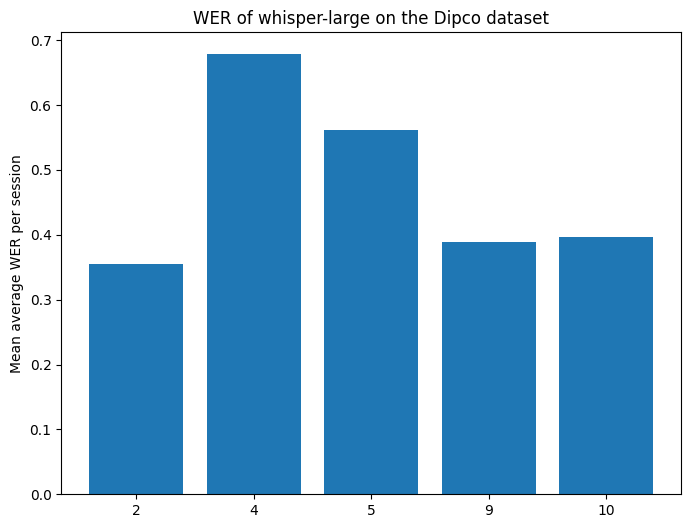

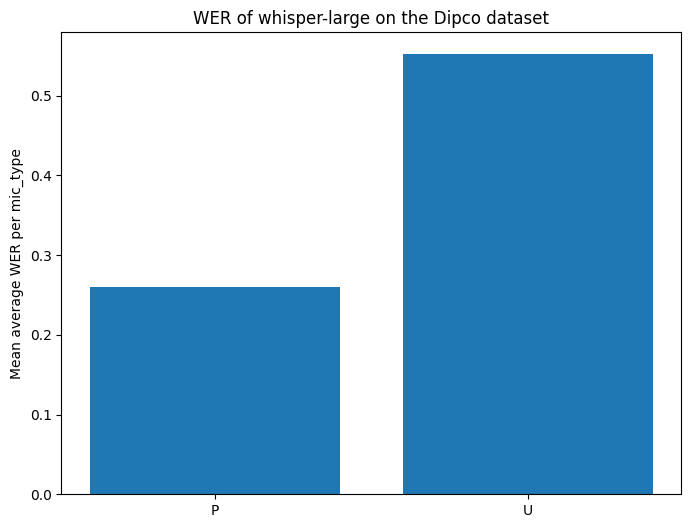

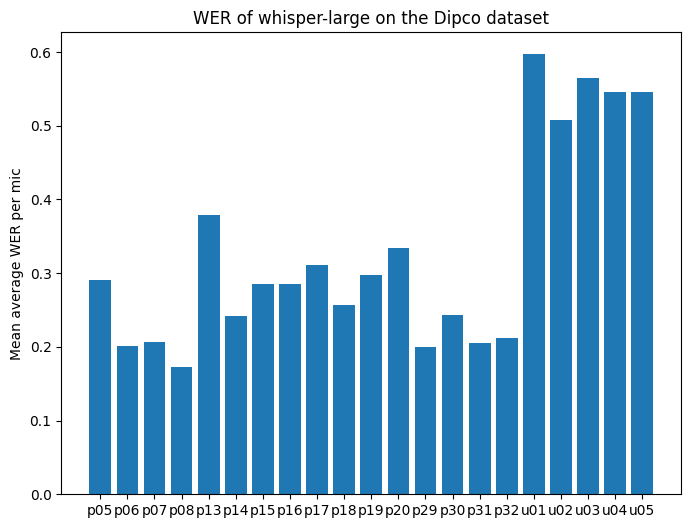

In [43]:
# plot visualization of the different sessions and store the results
import ast
import re
import matplotlib.pyplot as plt
def visualize_wer(grouped, type):
    names = []
    wers = []
    for name, group in grouped:
    
        wer = jiwer.wer(list(group["reference_clean"]), list(group["hypothesis_clean"]))
        

        # Regular expression to check if the string is a tuple representation
        tuple_pattern = r"\(\s*'[^']*'\s*,\s*'[^']*'\s*\)"
        
        # Check if the input string matches the tuple pattern
        if re.fullmatch(tuple_pattern, str(name)):
            # Safely evaluate the string to get the tuple
            parsed_tuple = ast.literal_eval(str(name))
        
            # Concatenate the elements and convert to lowercase
            result_str = f"{parsed_tuple[0].lower()}{parsed_tuple[1]}"
            names.append(result_str)
           
        else:
            names.append(str(name))
            
        
        wers.append(wer)
    plt.figure(figsize=(8, 6))
    plt.bar(names, wers)
    plt.ylabel(f'Mean average WER per {type[0]}')
    model_name = type[2].rsplit('/', 1)[-1]
    plt.title(f'WER of {model_name} on the {(dataset_name:=(type[1]))} dataset')
   
    plt.savefig(f'Figures/{(partition_type:=(type[0]))} bar_plot.png', format='png')
    plt.show()
    
directory = "Figures"

# Create the directory if it doesn't exist
if not os.path.exists(directory):
    os.makedirs(directory)
    print(f"Directory '{directory}' created.")
else:
    print(f"Directory '{directory}' already exists.")      
visualize_wer(grouped_ses, ["session", f"{dataset_name}", f"{model_name}"])
visualize_wer(grouped_mic_type, ["mic_type", f"{dataset_name}", f"{model_name}"])
visualize_wer(grouped_mic, ["mic", f"{dataset_name}", f"{model_name}"])



In [44]:
error_rates = data['wer'].apply(lambda x: x.error_rate)

# Calculate the mean of the error rates
mean_error_rate = error_rates.mean()
print(mean_error_rate)

0.9471241605853301


In [45]:
import smtplib
import ssl
from email.message import EmailMessage

# Define email sender and receiver
email_sender = 'uhicv@student.kit.edu'
email_password = '***REMOVED***'
email_receiver = 'uhicv@student.kit.edu'

# Set the subject and body of the email
subject = 'Test has finished'
body = """
I've just published a new video on YouTube: https://youtu.be/2cZzP9DLlkg
"""

em = EmailMessage()
em['From'] = email_sender
em['To'] = email_receiver
em['Subject'] = subject
em.set_content(body)

# Add SSL (layer of security)
context = ssl.create_default_context()

# Log in and send the email
with smtplib.SMTP_SSL('smtp.gmail.com', 465, context=context) as smtp:
    smtp.login(email_sender, email_password)
    smtp.sendmail(email_sender, email_receiver, em.as_string())

SMTPAuthenticationError: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials 5b1f17b1804b1-429c751a547sm107274415e9.23 - gsmtp')

In [ ]:
from huggingface_hub import notebook_login
#***REMOVED***
#notebook_login()